STL 10 Zero shot Classification

In [2]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-5lbdete9
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-5lbdete9
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369547 sha256=b94e3ac3bad9a88c44e7902dbd312529ab5ee71578ea5d50be3ac8bbdbbc0dc5
  Stored in directory: /tmp/pip-ephem-wheel-cache-c7ibtdqs/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import torch
import clip
import torchvision
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
from tqdm import tqdm

#setting up standard clip model and preprocessor
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

#loading stl dataset and we want just the test split
test_dataset = STL10(root='./data', split='test', download=True, transform=preprocess)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)
classes = test_dataset.classes

#three strats taken from the guide(third made after analysing dataset images)
templates = {
    "Plain Labels": [f"{c}" for c in classes],
    "Prompted Text": [f"a photo of a {c}" for c in classes],
    "Descriptive Text": [f"high-quality close-up photo of a {c} outside" for c in classes]
}

#function to test zeroshot accuracy
def evaluate_zeroshot(model, dataloader, text_prompts, device):
    #exttracting text features
    text_inputs = clip.tokenize(text_prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            #extracting image features
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            #cosine similarity comparison
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            
            #most similar prediction
            _, predicted = similarity.max(1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return (correct / total) * 100

#for each strat run eval and display
accuracies = {}
for strategy_name, prompts in templates.items():
    print(f"Strategy: {strategy_name}")
    acc = evaluate_zeroshot(model, test_loader, prompts, device)
    accuracies[strategy_name] = acc
    print(f"Accuracy: {acc:.2f}%\n")

print("RESULTS")
for strategy, acc in accuracies.items():
    print(f"{strategy}: {acc:.2f}%")

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 106MiB/s]


Strategy: Plain Labels


Evaluating: 100%|██████████| 32/32 [00:11<00:00,  2.83it/s]


Accuracy: 96.26%

Strategy: Prompted Text


Evaluating: 100%|██████████| 32/32 [00:11<00:00,  2.81it/s]


Accuracy: 97.36%

Strategy: Descriptive Text


Evaluating: 100%|██████████| 32/32 [00:11<00:00,  2.79it/s]

Accuracy: 95.84%

RESULTS
Plain Labels: 96.26%
Prompted Text: 97.36%
Descriptive Text: 95.84%


Modality Gap

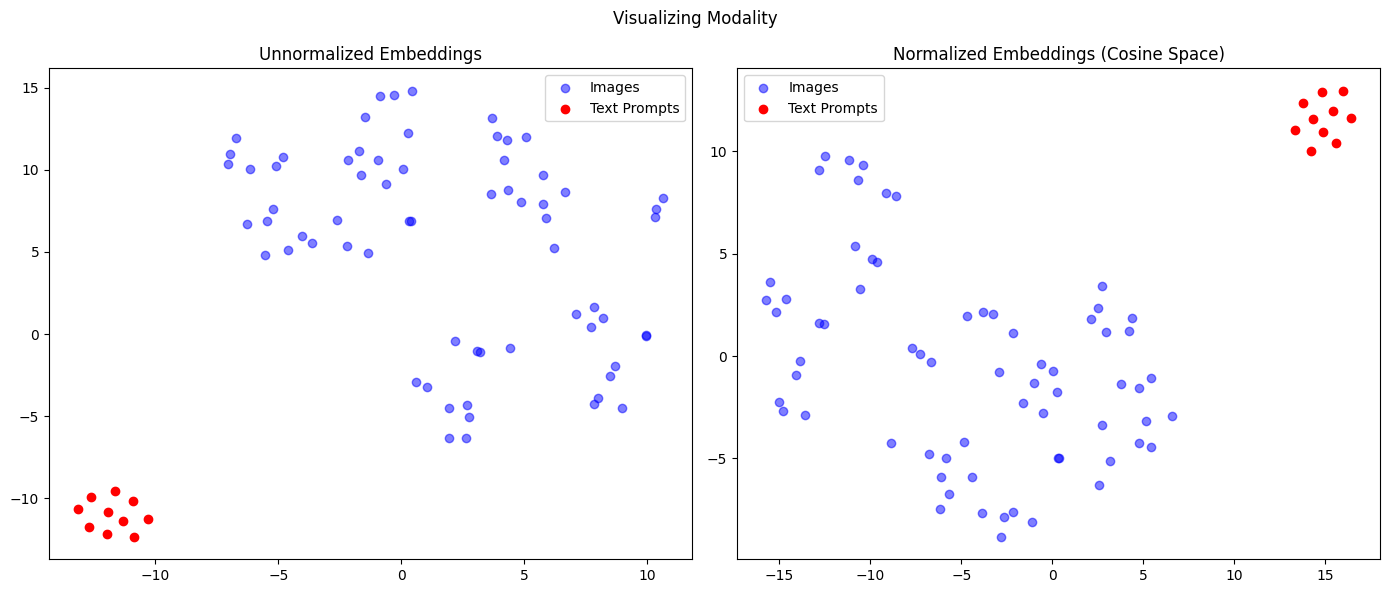

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import torch

#grabbing 67 images from the loader
images, labels = next(iter(test_loader))
images = images[:67].to(device)

# extracting norm and unnorm image embeddings
with torch.no_grad():
    image_features_unnorm = model.encode_image(images)
    image_features_norm = image_features_unnorm / image_features_unnorm.norm(dim=-1, keepdim=True)

# text embedding for all 10 classes
text_prompts = [f"a photo of a {c}" for c in classes]
text_inputs = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features_unnorm = model.encode_text(text_inputs)
    text_features_norm = text_features_unnorm / text_features_unnorm.norm(dim=-1, keepdim=True)

#conversion for tsne
img_unnorm = image_features_unnorm.cpu().numpy()
img_norm = image_features_norm.cpu().numpy()
txt_unnorm = text_features_unnorm.cpu().numpy()
txt_norm = text_features_norm.cpu().numpy()
X_unnorm = np.vstack((img_unnorm, txt_unnorm))
X_norm = np.vstack((img_norm, txt_norm))

#running dimensionality reduction
tsne = TSNE(n_components=2, perplexity=15, random_state=14)
X_unnorm_2d = tsne.fit_transform(X_unnorm)
X_norm_2d = tsne.fit_transform(X_norm)

#plotting both figures
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

def plot_gap(ax_obj, X_2d, title):
    ax_obj.scatter(X_2d[:67, 0], X_2d[:67, 1], c='blue', label='Images', alpha=0.5)
    ax_obj.scatter(X_2d[67:, 0], X_2d[67:, 1], c='red',label='Text Prompts')
    ax_obj.set_title(title)
    ax_obj.legend()

plot_gap(ax[0], X_unnorm_2d, "Unnormalized Embeddings")
plot_gap(ax[1], X_norm_2d, "Normalized Embeddings (Cosine Space)")

plt.suptitle("Visualizing Modality")
plt.tight_layout()
plt.show()

Orthogonal Procrustes

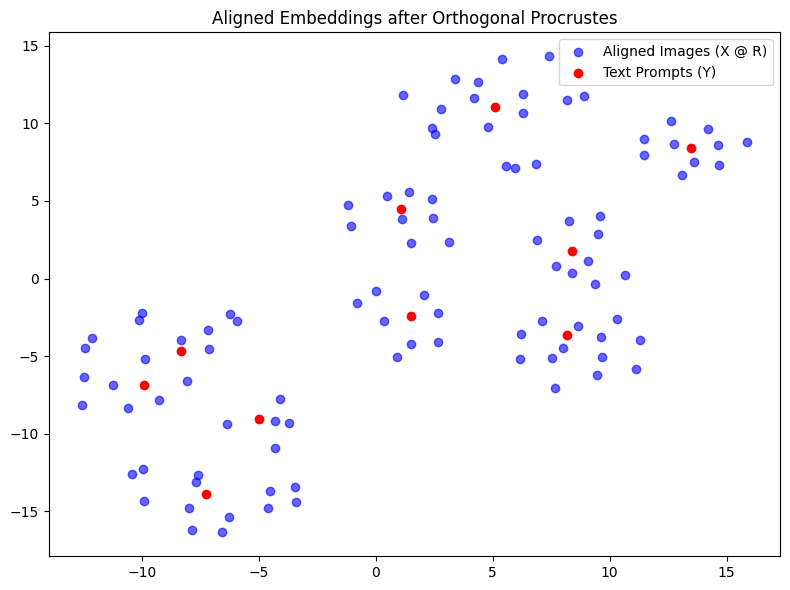


Original 'Prompted Text' Accuracy: 97.36%
Aligned Procrustes Zero-Shot Accuracy: 97.94%


In [7]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from sklearn.manifold import TSNE
from tqdm import tqdm
from torchvision.datasets import STL10
from torch.utils.data import DataLoader


device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

#loading stl dataset and we want just the test split
test_dataset = STL10(root='./data', split='test', download=True, transform=preprocess)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)
prompt_template = "a photo of a {}"
classes = test_dataset.classes
class_prompts = [prompt_template.format(c) for c in classes]
text_tokens = clip.tokenize(class_prompts).to(device)

with torch.no_grad():
    text_embeddings_all = model.encode_text(text_tokens)
    text_embeddings_all /= text_embeddings_all.norm(dim=-1, keepdim=True)
    text_embeddings_all = text_embeddings_all.float()
#need a set of paired embeddings
X_list = []
Y_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        img_feats = model.encode_image(images)
        img_feats /= img_feats.norm(dim=-1, keepdim=True)
        
        #text embeddings
        txt_feats = text_embeddings_all[labels.to(device)]
        
        X_list.append(img_feats.cpu().numpy())
        Y_list.append(txt_feats.cpu().numpy())

X = np.vstack(X_list).astype(np.float32)
Y = np.vstack(Y_list).astype(np.float32)

#finding the matrix R
R, _ = orthogonal_procrustes(X, Y)

#applying R to X and normalizing
X_aligned = X @ R
X_aligned = X_aligned / np.linalg.norm(X_aligned, axis=-1, keepdims=True)

#tsne subplot for 100 embeddings
txt_np = text_embeddings_all.cpu().numpy()
subset_X_aligned = X_aligned[:100]

combined_aligned = np.vstack((subset_X_aligned, txt_np))
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
aligned_2d = tsne.fit_transform(combined_aligned)

plt.figure(figsize=(8, 6))
plt.scatter(aligned_2d[:100, 0], aligned_2d[:100, 1], c='blue', alpha=0.6, label='Aligned Images (X @ R)')
plt.scatter(aligned_2d[100:, 0], aligned_2d[100:, 1], c='red', label='Text Prompts (Y)')
plt.title("Aligned Embeddings after Orthogonal Procrustes")
plt.legend()
plt.tight_layout()
plt.show()

#caluculateing accuracy after alignment
X_aligned_tensor = torch.tensor(X_aligned, dtype=torch.float32, device=device)

# Compute similarity in aligned space: (N, 10)
similarity_aligned = (100.0 * X_aligned_tensor @ text_embeddings_all.T).softmax(dim=-1)
_, predicted_aligned = similarity_aligned.max(dim=1)

#ground truth labels
all_labels = torch.tensor(test_dataset.labels, device=device)
correct = (predicted_aligned == all_labels).sum().item()
total = len(all_labels)

aligned_acc = (correct / total) * 100
print(f"\nOriginal 'Prompted Text' Accuracy: 97.36%")
print(f"Aligned Procrustes Zero-Shot Accuracy: {aligned_acc:.2f}%")